In [1]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

1. LOADING THE MERGED DATAFRAME

In [2]:
df = pd.read_csv('../clean_data/df_clean.csv')

# Checking few rows of the dataframe
df.sample(7)

,TransactionId,UserId,VisitYear,VisitMonth,VisitModeId,AttractionId,Rating,CityId,CityName,CountryId,...,RegionId,Region,ContinentId,Continent,AttractionCityId,AttractionTypeId,Attraction,AttractionType,VisitMode,Month
35702,72849,11620,2016,3,2,748,3,3567,Bangkok,107,...,14,South East Asia,3,Asia,1,72,Tegalalang Rice Terrace,Points of Interest & Landmarks,Couples,March
6431,9416,57985,2017,5,2,640,5,426,London,48,...,8,Northern America,2,America,1,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Couples,May
16327,24803,60286,2016,8,4,841,4,8513,Leeds,163,...,21,Western Europe,5,Europe,1,92,Waterbom Bali,Water Parks,Friends,August
9314,13472,53550,2015,10,2,640,4,6677,Lund,145,...,19,Northern Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Couples,October
32312,68119,35100,2016,9,2,748,4,2981,Bandar Seri Begawan,98,...,14,South East Asia,3,Asia,1,72,Tegalalang Rice Terrace,Points of Interest & Landmarks,Couples,September
32409,68249,57462,2016,4,4,748,4,3013,Bali,101,...,14,South East Asia,3,Asia,1,72,Tegalalang Rice Terrace,Points of Interest & Landmarks,Friends,April
44385,146739,22325,2016,11,2,369,2,426,London,48,...,8,Northern America,2,America,1,13,Kuta Beach - Bali,Beaches,Couples,November


2. EXPLORATORY DATA ANALYSIS

I. Visualising Tourism based on the years.

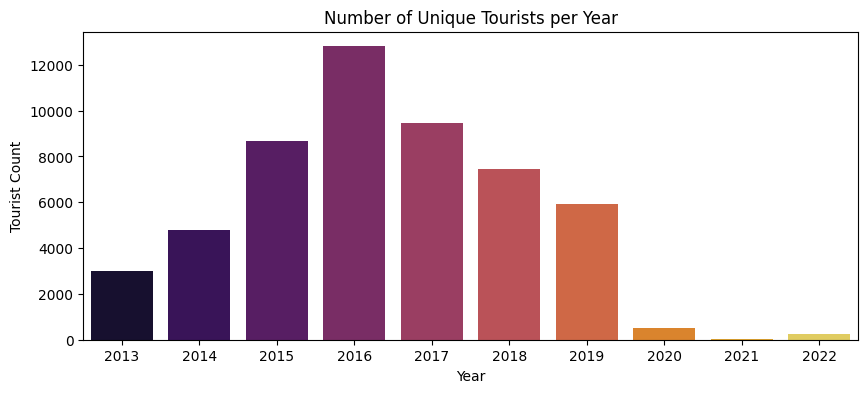

In [ ]:
def plot_tourism_trends_year(df):
    # Calculating the number of unique tourists for every year
    tpy = df.groupby('VisitYear')['UserId'].count().reset_index()

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.barplot(data=tpy, x='VisitYear', y='UserId', palette='inferno', ax=ax)
    ax.set_title('Number of Unique Tourists per Year')
    ax.set_xlabel('Year')
    ax.set_ylabel('Tourist Count')
    return fig

fig = plot_tourism_trends_year(df)
plt.show()

Insights-
- From the graph we can see that how drastically tourism was affected due to the Covid-19 pandemic. So the years after 2019, the tourism activities decreased very significantly, with 2021 being the most affected.
- We can see a gradual increase in tourism up to the year of 2016, when the count of tourists was the highest, after which the tourism activities slowly declined, and also even much more during and after the pandemic, with 2021 with the lowest tourist count.

II. Visualising Tourism activities of every Month.

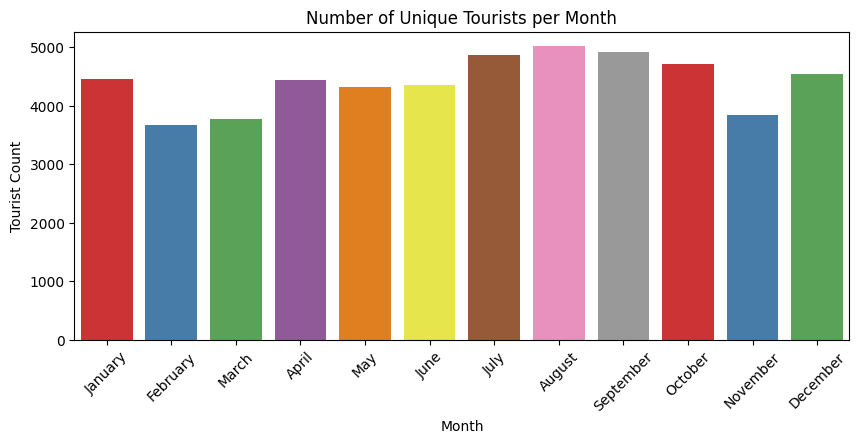

In [13]:
def plot_tourism_trends_month(df):
    # To keep the months in the correct order
    month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
    df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
    
    # Calculting the number of tourists for every month
    tpm = df.groupby('Month')['UserId'].count().sort_values(ascending=False).reset_index()

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.barplot(data=tpm, x='Month', y='UserId', palette='Set1', ax=ax)
    ax.set_title('Number of Unique Tourists per Month')
    ax.set_xlabel('Month')
    ax.set_ylabel('Tourist Count')
    plt.xticks(rotation=45)
    return fig

fig = plot_tourism_trends_month(df)
plt.show()

Insights-
- August, September and July show consistently high tourist activities and the highest tourist counts.
- November and February have the lowest Tourist counts.

III. Visualising the distribution of rating given by the tourists.

Skewness: -1.1984556512614286
Kurtosis: 1.166991981223637


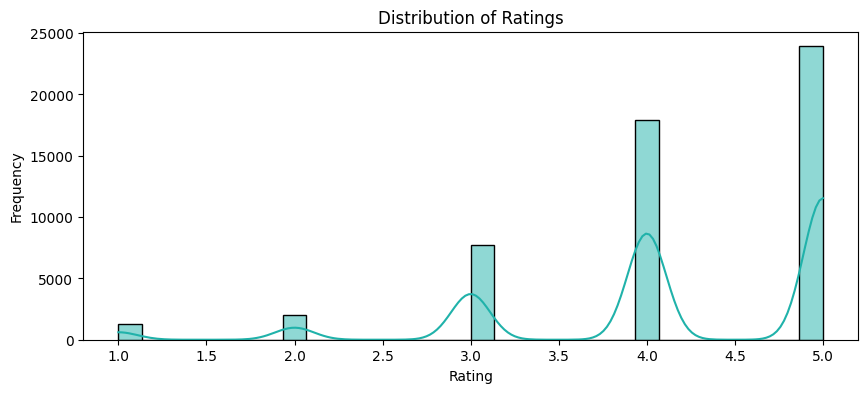

In [14]:
# Calculating the skewness and kurtosis
print(f"Skewness: {df['Rating'].skew()}")
print(f"Kurtosis: {df['Rating'].kurt()}")

def plot_rating_distribution(df):
    # Plotting the histogram
    fig, ax = plt.subplots(figsize=(10,4))
    sns.histplot(df['Rating'], bins=30, kde=True, color='lightseagreen', ax=ax)
    ax.set_title('Distribution of Ratings')
    ax.set_xlabel('Rating')
    ax.set_ylabel('Frequency')
    return fig

fig = plot_rating_distribution(df)
plt.show()

Insights-
- The histogram shows that the count of 5⭐ rating is the highest. This shows that the tourists were very satisfied with the attraction places that they visited.
- The skewness value suggests that the data is left skewed (negative skewness).
- The kurtosis values shows that the data is leptokurtic (sharp peak, kurtosis is positive).

IV. Visualising the average rating by Attraction type.

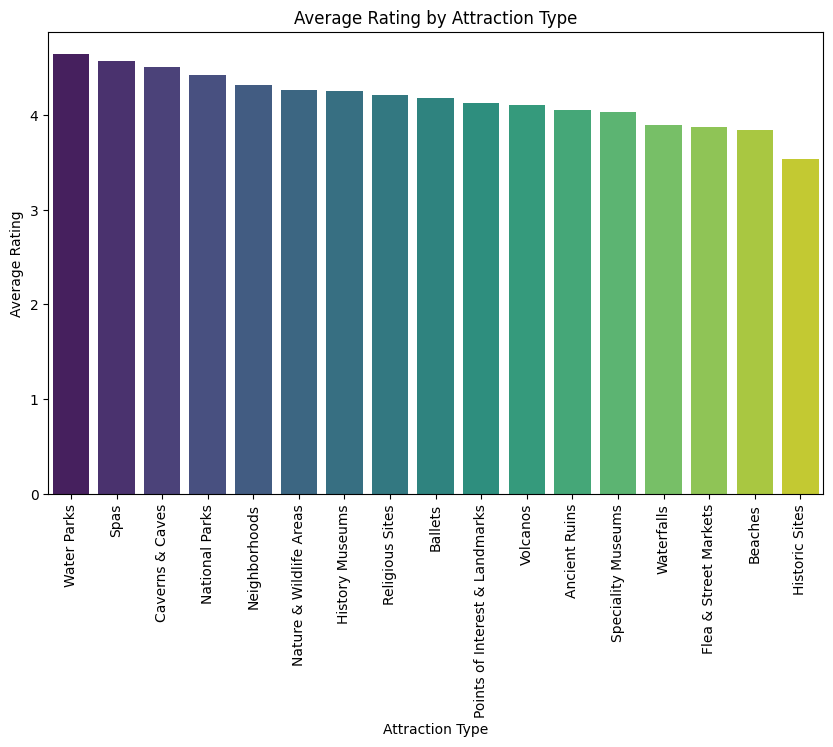

In [16]:
def plot_avg_rating_by_attr_type(df):
    # Calculating the average rating by attraction type
    avg_attr_rating = df.groupby('AttractionType')['Rating'].mean().reset_index().sort_values(ascending=False, by='Rating')

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,6))
    sns.barplot(data=avg_attr_rating, x='AttractionType', y='Rating', palette='viridis', ax=ax)
    ax.set_title('Average Rating by Attraction Type')
    ax.set_xlabel('Attraction Type')
    ax.set_ylabel('Average Rating')
    plt.xticks(rotation=90)
    return fig

fig = plot_avg_rating_by_attr_type(df)
plt.show()

Insights-
- Water Parks are the highest rated atraction type followed by Spas and, Caverns and caves.
- The markets, beaches and historic sites are the least rated.
- Most of the attraction types are rated 4⭐ and above, which shows that the places that come under these categories are well maintained and meet the expectations of the tourists.

V. Visualising the count of tourists of each type (Business, Solo, etc).

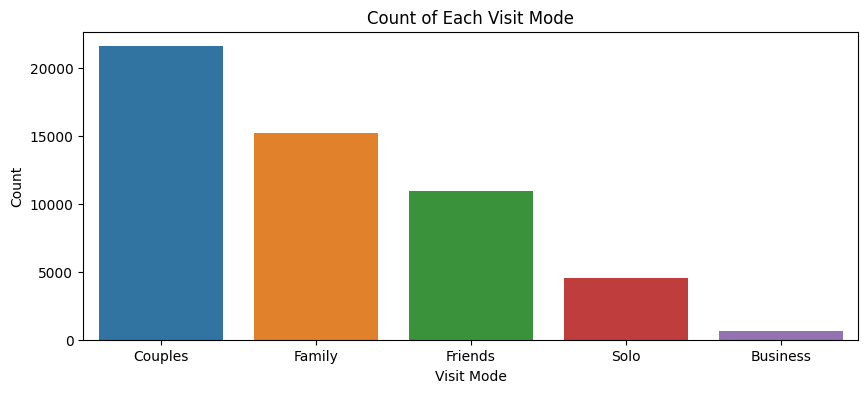

In [17]:
def plot_count_visitmode(df):
    # Calculating the count of each visit mode
    visit_mode_count = df['VisitMode'].value_counts().reset_index()
    visit_mode_count.columns = ['VisitMode', 'Count']

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.barplot(data=visit_mode_count, x='VisitMode', y='Count', palette='tab10', ax=ax)
    ax.set_title('Count of Each Visit Mode')
    ax.set_xlabel('Visit Mode')
    ax.set_ylabel('Count')
    return fig

fig = plot_count_visitmode(df)
plt.show()

Insights-
- Couples are the dominant tourist segment by count.
- Business trips are the smallest segment of tourists.

VI. Visualising the average ratings each type of tourists (solo, couple, business, etc.) provide.

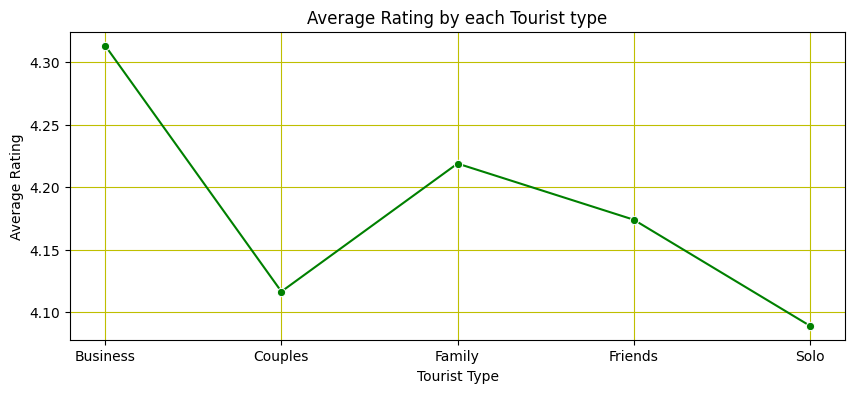

In [18]:
def plot_avg_type_tourist_rating(df):
    # Calculating the average rating given by each tourist type
    avg_ratings = df.groupby('VisitMode')['Rating'].mean().reset_index()
    
    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.lineplot(data=avg_ratings, x='VisitMode', y='Rating', color='g', marker='o', ax=ax)
    ax.set_title('Average Rating by each Tourist type')
    ax.grid(color='y')
    ax.set_xlabel('Tourist Type')
    ax.set_ylabel('Average Rating')
    return fig

fig = plot_avg_type_tourist_rating(df)
plt.show()

Insights-
- Although the difference between the average rating of each type of tourists is low, tourists on a business trip have provided a higher rating than the other categories of tourists, for any particular location. Likely due to premium services and efficiency.
- Tourists on family trips have rated higher than Couples and Friend groups likely because the attraction places offer services that cater better experiences towards Families.
- People who go on solo trips have provided the lowest rating; Couples also provide low ratings although it is slightly higher than Solo travellers.

VII. Visualising the attraction types most visited by each type of tourists.

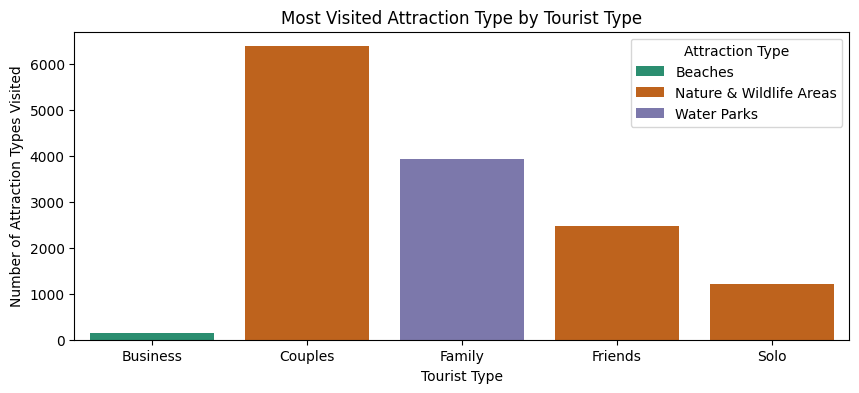

In [19]:
def plot_prfrd_attr_by_tourist_type(df):
    # Calculating the most visited attraction type for each tourist type
    preferred_attr = df.groupby(['VisitMode', 'AttractionType']).size().reset_index(name='Count')
    preferred_attr = preferred_attr.sort_values(ascending=False, by='Count').groupby('VisitMode').first().reset_index()

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.barplot(data=preferred_attr, x='VisitMode', y='Count', hue='AttractionType', palette='Dark2', ax=ax)
    ax.set_title('Most Visited Attraction Type by Tourist Type')
    ax.set_xlabel('Tourist Type')
    ax.set_ylabel('Number of Attraction Types Visited')
    ax.legend(title='Attraction Type')
    return fig

fig = plot_prfrd_attr_by_tourist_type(df)
plt.show()

Insights-
- Business trips focus mainly on Beaches for their tours.
- Couples, Friend groups and Solo travellers prefer visiting Nature and Wildlife Areas.
- Family segment prefer visiting Water Parks.

VIII. Visualising activities of each Visit Mode by Month.

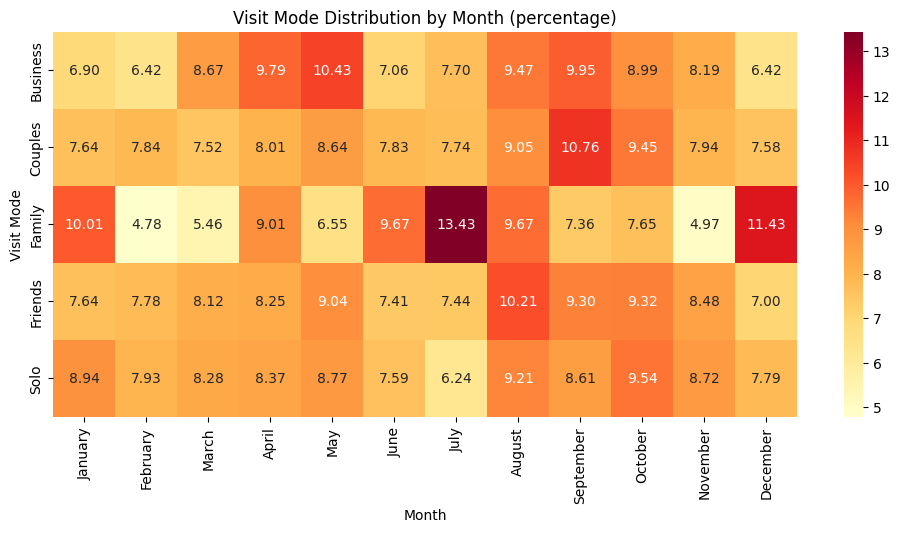

In [20]:
def plot_mode_by_month(df):
    # To keep the months in the correct order
    month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
    df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
    
    # Calculating the count of each visit mode for each month
    count = pd.crosstab(df['VisitMode'], df['Month'])

    # Converting the count to percentage
    pct = count.div(count.sum(axis=1), axis=0)*100

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(12,5))
    sns.heatmap(pct, annot=True, cmap='YlOrRd', fmt='.2f', ax=ax)
    ax.set_title('Visit Mode Distribution by Month (percentage)')
    ax.set_xlabel('Month')
    ax.set_ylabel('Visit Mode')
    return fig

fig = plot_mode_by_month(df)
plt.show()

Insights-
- May: Business Trip-heavy month.
- September: Couple-heavy month.
- July, December and January: Family-heavy month.
- August: Friends-heavy month.
- October: Solo-heavy month.
- Solo trips are evenly distributed across the whole year.
- Friends group travel is also distributed almost evenly across the whole year, but with slightly more clusering during the summer and early autumn.
- Family trips seems to be dependant more on school holidays, since we can see the peak during July and June, and in the winter months of December and January.
- Couples' travelling is clustered around the early autumn.
- Business Trips seems to depend on the corporate cycles, and drops during the holiday season (January, Februry and December).

IX. Visualising the top 10 most visited attractions.

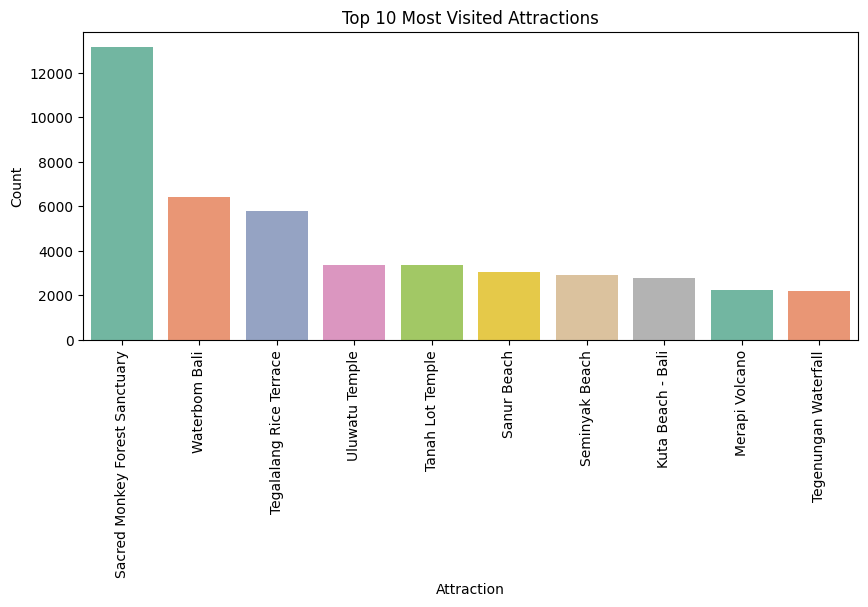

In [21]:
def plot_top_ten_attr(df):
    # Calculating the top 10 most visited attraction types
    top_attr = df['Attraction'].value_counts().head(10).reset_index()
    top_attr.columns = ['Attraction', 'Count']

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.barplot(data=top_attr, x='Attraction', y='Count', palette='Set2', ax=ax)
    ax.set_title('Top 10 Most Visited Attractions')
    ax.set_xlabel('Attraction')
    ax.set_ylabel('Count')
    plt.xticks(rotation=90)
    return fig

fig = plot_top_ten_attr(df)
plt.show()

Insights-
- Sacred Monkey Forest Sanctuary, which comes under Nature and Wildlife Areas, is the highest visited attraction. This type of attraction is the highest visited and most popular among Couples, Solo travellers and Friends group.
- Tegenungan Waterfall, which comes under the waterfalls category, stands as the tenth most visited attraction.

X. Visualising the number of interactions per user.

Skewness of User Interactions: 7.933534209785179
Kurtosis of User Interactions: 176.52398064440203


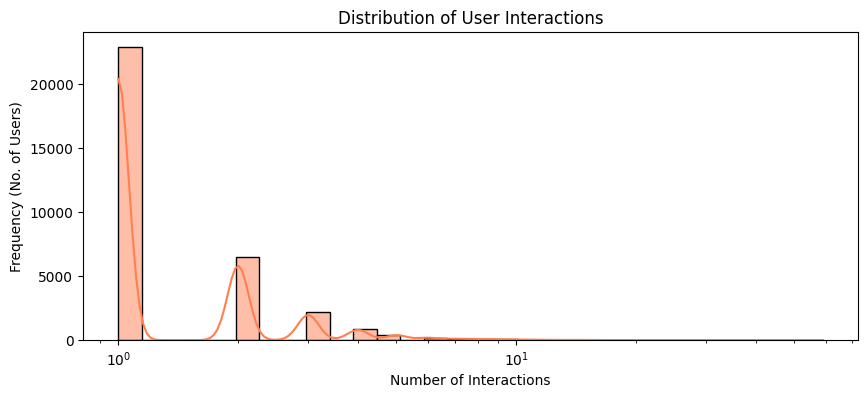

In [22]:
# Calculating skewness and kurtosis for the number of interactions per user
user_interactions = df.groupby('UserId').size()
print(f"Skewness of User Interactions: {user_interactions.skew()}")
print(f"Kurtosis of User Interactions: {user_interactions.kurt()}")

def plot_user_interactions(df):
    # Calculating the number of interactions for each user
    user_interactions = df.groupby('UserId').size()

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.histplot(user_interactions, bins=30, color='coral', log_scale=True, kde=True, ax=ax)
    ax.set_title('Distribution of User Interactions')
    ax.set_xlabel('Number of Interactions')
    ax.set_ylabel('Frequency (No. of Users)')
    return fig

fig = plot_user_interactions(df)
plt.show()

Insights-
- The skewness and kurtosis are both positive which indicates the data to be right-skewed and leptokurtic (sharp peak).
- Majority of users have very low interactions.
- Extreme outliers exist, that is, a small group of users with high interaction count, which makes the skewness and kurtosis values high.

XI. Visualising the number of interactions per attraction.

Skewness of Attraction Interactions: 2.79975613031877
Kurtosis of Attraction Interactions: 9.662963665080667


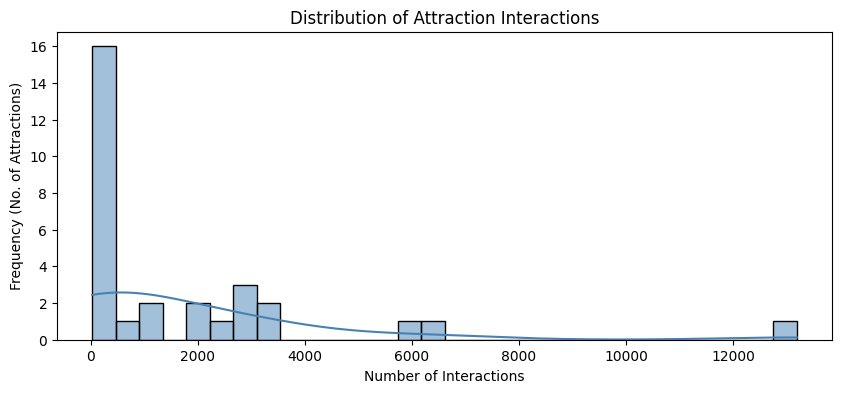

In [23]:
# Calculating the skewness and kurtosis
attr_interactions = df.groupby('Attraction').size()
print(f"Skewness of Attraction Interactions: {attr_interactions.skew()}")
print(f"Kurtosis of Attraction Interactions: {attr_interactions.kurt()}")

def plot_attr_interactions(df):
    # Calculating the number of interactions for each attraction
    attr_interactions = df.groupby('Attraction').size()

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.histplot(attr_interactions, bins=30, color='steelblue', kde=True, ax=ax)
    ax.set_title('Distribution of Attraction Interactions')
    ax.set_xlabel('Number of Interactions')
    ax.set_ylabel('Frequency (No. of Attractions)')
    return fig

fig = plot_attr_interactions(df)
plt.show()

Insights-
- The skewness and kurtosis is positive, which is shown by the right-skewed nature of the graph and its sharp peak.
- Most attractions receive very few interactions.
- Few attractions receive high interactions and these can likely be termed "tourist hotspots".